## **Parte 1: Probabilidad**

Don Jaime es el dueño del kiosko ubicado en Av. Córdoba y Reconquista. Nos pide ayuda para completar su inventario y así poder comprender el comportamiento de sus clientes. Estas son sus heladeras con bebidas frescas.

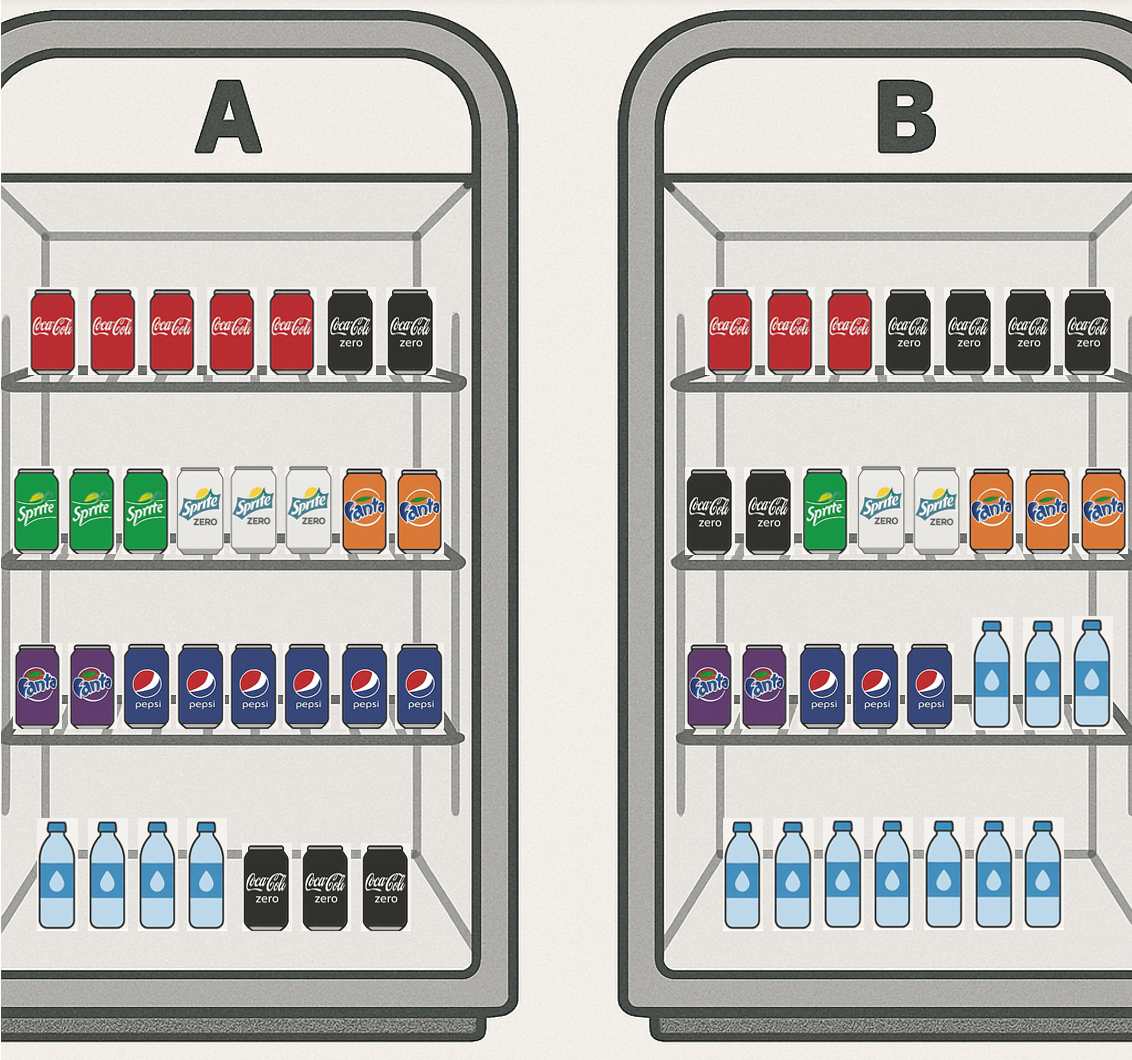

In [3]:
# 1. Almacenar la información acerca de la cantidad de bebidas en cada heladera en dos listas de nombre heladera_a y heladera_b.
heladera_a = [
    "Coca-Cola", "Coca-Cola", "Coca-Cola", "Coca-Cola", "Coca-Cola","Coca-Cola Zero", "Coca-Cola Zero",
    "Sprite", "Sprite", "Sprite Zero", "Sprite Zero", "Fanta", "Fanta",
    "Fanta Uva", "Fanta Uva", "Pepsi", "Pepsi", "Pepsi", "Pepsi","Pepsi","Pepsi",
    "Agua", "Agua", "Agua", "Agua", "Coca-Cola Zero","Coca-Cola Zero", "Coca-Cola Zero"
             ]
heladera_b = [
    "Coca-Cola", "Coca-Cola", "Coca-Cola Zero", "Coca-Cola Zero", "Coca-Cola Zero",
    "Coca-Cola Zero", "Coca-Cola Zero","Coca-Cola Zero", "Sprite", "Sprite Zero", "Sprite Zero", "Fanta", "Fanta", "Fanta",
    "Fanta Uva", "Fanta Uva", "Pepsi", "Pepsi", "Pepsi", "Agua", "Agua", "Agua",
    "Agua", "Agua", "Agua", "Agua", "Agua","Agua","Agua"
             ]

In [52]:
# 2. ¿Cuántas bebidas de cada tipo hay en total?

import numpy as np
heladeragral = {}

def union(lista_1, lista_2):
    arr1 = np.array(lista_1 + lista_2)
    producto, cantidad = np.unique(arr1, return_counts=True)
    for i in range(len(producto)):
        heladeragral[str(producto[i])] = int(cantidad[i])
    return f'el stock se forma así:\n{heladeragral}'

print(union(heladera_a, heladera_b))



el stock se forma así:
{'Agua': 14, 'Coca-Cola': 7, 'Coca-Cola Zero': 11, 'Fanta': 5, 'Fanta Uva': 4, 'Pepsi': 9, 'Sprite': 3, 'Sprite Zero': 4}


In [55]:
# 3. ¿Cuántas bebidas de cada tipo hay tanto en la heladera A como en la heladera B?
conteo = {}
conteo2 = {}
for bebida in heladera_a:
    conteo[bebida] = conteo.get(bebida, 0) +1 #busca la key bebida, si no existe le asigna un 0 como valor y le suma uno, si existe le suma uno al valor guardado
for bebida in heladera_b:
    conteo2[bebida] = conteo2.get(bebida, 0) +1
minimos = {}
for bebida in conteo.keys():
    minimos[bebida] = min(conteo[bebida],conteo2[bebida])
minimos

{'Coca-Cola': 2,
 'Coca-Cola Zero': 5,
 'Sprite': 1,
 'Sprite Zero': 2,
 'Fanta': 2,
 'Fanta Uva': 2,
 'Pepsi': 3,
 'Agua': 4}

In [56]:
# 4. ¿Cuántas bebidas de cada tipo hay en la heladera A que no haya en la heladera B? ¿Y al revés?



def contar_bebidas(lista):
    arr = np.array(lista)
    producto, cantidad = np.unique(arr, return_counts=True)
    return {str(producto[i]): int(cantidad[i]) for i in range(len(producto))}

heladeraA = contar_bebidas(heladera_a)
heladeraB = contar_bebidas(heladera_b)

faltantes = []

for bebida in set(heladeraA.keys()).union(heladeraB.keys()):
    cantA = heladeraA.get(bebida, 0)
    cantB = heladeraB.get(bebida, 0)

    if cantA < cantB:  # le faltan a A
        faltantes.append(f"A necesita {cantB - cantA} {bebida}")
    if cantB < cantA:  # le faltan a B
        faltantes.append(f"B necesita {cantA - cantB} {bebida}")

print(faltantes)

['B necesita 3 Coca-Cola', 'A necesita 1 Coca-Cola Zero', 'A necesita 1 Fanta', 'A necesita 6 Agua', 'B necesita 3 Pepsi', 'B necesita 1 Sprite']


In [43]:

# 5. ¿Cuál es la probabilidad de que un cliente elija una Coca-Cola Zero?
import numpy as np
def probabilidad(producto):
  total = 0
  for i in heladeragral.values():
    total += i
  stat = heladeragral[producto] / total
  return f'la probabilidad de que elija {producto} es del {(stat*100):.2f}%'
probabilidad("Coca-Cola Zero")

'la probabilidad de que elija Coca-Cola Zero es del 19.30%'

In [42]:
# 6. ¿Cuál es la probabilidad de que un cliente elija una Fanta, sin importar el sabor?
import numpy as np
def probabilidad2(producto, producto2):
  total = 0
  for i in heladeragral.values():
    total += i
  stat1 = heladeragral[producto] / total
  stat2 = heladeragral[producto2] / total
  stat3 = stat1 + stat2
  return f'la probabilidad de que elija {producto} y {producto2} es del {(stat3*100):.2f}%'
probabilidad2("Fanta Uva","Fanta")

'la probabilidad de que elija Fanta Uva y Fanta es del 15.79%'

In [39]:
# 7. ¿Cuál es la probabilidad de que un cliente elija una botella de agua, luego de haber abierto la heladera A?
from collections import Counter
prob = heladera_a.count("Agua") / (len(heladera_a))
print(f'el cliente tiene un {(prob*100):.2f}% de probabilidad de hacerlo')

el cliente tiene un 14.29% de probabilidad de hacerlo


In [53]:
# 8. Las ventas del día de hoy fueron las siguientes.
# Heladera A: 1 Fanta Naranja, 2 Pepsi, 2 Coca-Cola Zero y 1 Sprite Regular.
# Heladera B: 3 Aguas, 1 Coca-Cola Zero y 1 Sprite Zero.
# Actualizar las listas.
ventas_A = {
    "Fanta": 1,
    "Pepsi": 2,
    "Coca-Cola Zero": 2,
    "Sprite": 1
}

ventas_B = {
    "Agua": 3,
    "Coca-Cola Zero": 1,
    "Sprite Zero": 1
}

def actualizar_heladera(lista, ventas):
    lista_actualizada = lista.copy()
    for producto, cantidad in ventas.items():
        for i in range(cantidad):
            if producto in lista_actualizada:
                lista_actualizada.remove(producto)
    return lista_actualizada

def ActStock():
    heladeragral_actualizada = heladeragral.copy()
    for producto , cantidad in ventas_A.items():
        if producto in heladeragral_actualizada.keys():
            heladeragral_actualizada[producto] -= cantidad
    for producto , cantidad in ventas_B.items():
        if producto in heladeragral_actualizada.keys():
            heladeragral_actualizada[producto] -= cantidad
    return heladeragral_actualizada




heladera_a_actualizada = actualizar_heladera(heladera_a, ventas_A)
heladera_b_actualizada = actualizar_heladera(heladera_b, ventas_B)
stock = ActStock()
print("lista de stock actualizado: \n ", stock)
print("\n Heladera A actualizada:\n ", heladera_a_actualizada)
print("\n Heladera B actualizada:\n ", heladera_b_actualizada)



lista de stock actualizado: 
  {'Agua': 11, 'Coca-Cola': 7, 'Coca-Cola Zero': 8, 'Fanta': 4, 'Fanta Uva': 4, 'Pepsi': 7, 'Sprite': 2, 'Sprite Zero': 3}

 Heladera A actualizada:
  ['Coca-Cola', 'Coca-Cola', 'Coca-Cola', 'Coca-Cola', 'Coca-Cola', 'Sprite', 'Sprite Zero', 'Sprite Zero', 'Fanta', 'Fanta Uva', 'Fanta Uva', 'Pepsi', 'Pepsi', 'Pepsi', 'Pepsi', 'Agua', 'Agua', 'Agua', 'Agua', 'Coca-Cola Zero', 'Coca-Cola Zero', 'Coca-Cola Zero']

 Heladera B actualizada:
  ['Coca-Cola', 'Coca-Cola', 'Coca-Cola Zero', 'Coca-Cola Zero', 'Coca-Cola Zero', 'Coca-Cola Zero', 'Coca-Cola Zero', 'Sprite', 'Sprite Zero', 'Fanta', 'Fanta', 'Fanta', 'Fanta Uva', 'Fanta Uva', 'Pepsi', 'Pepsi', 'Pepsi', 'Agua', 'Agua', 'Agua', 'Agua', 'Agua', 'Agua', 'Agua']


In [36]:
# 9. Entran dos clientes al kiosko. Cada uno abre una heladera. ¿Cuál es la probabilidad de que uno se lleve un agua y otro se lleve una Pepsi?
#no considero que cada uno tenia un 50% de chances de abrir cada heladera
from collections import Counter
cliente_a_caso1 = heladera_a_actualizada.count("Agua") / len(heladera_a_actualizada)
cliente_b_caso1 = heladera_b_actualizada.count("Pepsi") / len(heladera_b_actualizada)
caso1= cliente_a_caso1 * cliente_b_caso1
cliente_a_caso2 = heladera_a_actualizada.count("Pepsi") / len(heladera_a_actualizada)
cliente_b_caso2 = heladera_b_actualizada.count("Agua") / len(heladera_b_actualizada)
caso2 = cliente_a_caso2 * cliente_b_caso2
probaTotal = caso1 + caso2
print(f'la probabilidad de que suceda eso es del {(probaTotal*100):.2f}%')

la probabilidad de que suceda eso es de 7.58%


In [35]:
# 10. Entra un padre con su hijo al kiosko y abren la heladera B. ¿Cuál es la probabilidad de que elijan la misma bebida?

def dosBebidadIG(Bebida):
    hijo = heladera_b_actualizada.count(Bebida) / len(heladera_b_actualizada)
    padre = (heladera_b_actualizada.count(Bebida) - 1) / (len(heladera_b_actualizada) -1)
    return  hijo * padre

acumuladorProba = 0
for i in heladeragral.keys():
    probabilidadT = dosBebidadIG(i)
    print(i, f'{round((probabilidadT * 100), 2)}%')
    acumuladorProba  += probabilidadT

print(f'la probabilidad de que elijan la misma bebida (suponiendo que son variables independientes) es de {(acumuladorProba*100):.2f}%'  )



Agua 7.61%
Coca-Cola 0.36%
Coca-Cola Zero 3.62%
Fanta 1.09%
Fanta Uva 0.36%
Pepsi 1.09%
Sprite 0.0%
Sprite Zero 0.0%
la probabilidad de que elijan la misma bebida (suponiendo que son variables independientes) es de 14.13%


## **Parte 2: Estadística Descriptiva**

Gracias a las cámaras de seguridad de su kiosko, Don Jaime pudo generar un listado con la cantidad de segundos que pasaron sus últimos 100 clientes dentro del local. Ahora, necesita nuestra ayuda para analizar esos datos usando estadística descriptiva.

✨ Generá una lista de 100 valores numéricos que representen los segundos que cada cliente pasó en el local. Tené en cuenta las siguientes condiciones:

1. La mayoría de los valores deberían estar entre 30 y 120 segundos.

2. Algunos valores pueden estar por debajo o por encima para simular casos extremos o outliers.

3. Asegurate de que ningún valor sea menor a 5.

💡 Tip: Podés usar funciones de generación aleatoria, como *np.random.normal*, y aplicar condiciones para corregir valores extremos si es necesario.

Luego, calcular las siguientes medidas:

*   Media.
*   Mediana.
*   Moda.
*   Rango Intercuartil.
*   Varianza.
*   Desviación Estándar.

🕒 Consigna adicional: ¿Cómo se distribuyen los tiempos dentro del kiosko?

In [13]:
import pandas as pd

df1 = pd.DataFrame({"A":[1,2], "B":[3,4]})
df2 = pd.DataFrame({"B":[5,6], "C":[7,8]})

# Concatenar por filas (outer)
outer_concat = pd.concat([df1, df2], axis=0, join="outer")

# Concatenar por filas (inner)
inner_concat = pd.concat([df1, df2], axis=0, join="inner")

print("Outer join (default):")
print(outer_concat)
print("\nInner join:")
print(inner_concat)

Outer join (default):
     A  B    C
0  1.0  3  NaN
1  2.0  4  NaN
0  NaN  5  7.0
1  NaN  6  8.0

Inner join:
   B
0  3
1  4
0  5
1  6


Don Jaime desea complementar esos datos con la cantidad de productos que el usuario compró. El siguiente listado contiene la cantidad de productos que compró cada uno de los usuarios, ordenados de la misma manera que la lista generada anteriormente.

```
compras = [0, 1, 2, 1, 0, 0, 3, 0, 2, 4, 0, 1, 0, 2, 3, 1, 0, 0, 2, 0,
 4, 1, 0, 0, 3, 2, 1, 1, 2, 3, 0, 5, 0, 2, 2, 1, 4, 0, 2, 0,
 0, 0, 3, 4, 2, 0, 0, 3, 2, 1, 1, 2, 0, 5, 0, 2, 2, 3, 0, 1,
 0, 4, 1, 2, 2, 3, 0, 0, 1, 1, 4, 0, 2, 0, 0, 2, 1, 3, 2, 1,
 2, 0, 0, 1, 0, 5, 1, 2, 3, 1, 0, 4, 1, 2, 0, 0, 0, 6, 0, 0]
```

Calcular la covarianza y la correlación entre la cantidad de segundos dentro del local y la cantidad de productos comprados.

📊 Crear una diapositiva para presentarle a Don Jaime los principales resultados de tu análisis. Subirla al WebCampus.